In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
!pip install xgboost

In [23]:
df= pd.read_csv("/content/BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [24]:
## Check for null values
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [25]:
df.duplicated().sum()

0

In [26]:
## check for shape
df.shape

(506, 14)

In [27]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'price'],
      dtype='object')

In [28]:
## Split the dataset
X= df.iloc[:,:-1]
y=df.iloc[:,-1]

<Axes: >

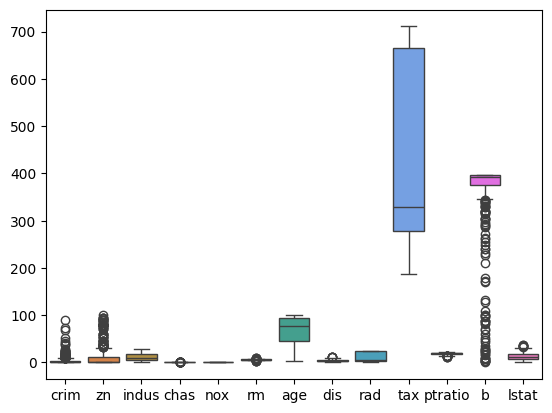

In [29]:
## check for outliers
sns.boxplot(X)

In [30]:
## use train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=7)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(379, 13) (379,)
(127, 13) (127,)


In [31]:
# from sklearn.preprocessing import StandardScaler

# scaler= StandardScaler()

# X_train= scaler.fit_transform(X_train)
# X_test= scaler.transform(X_test)

<Axes: >

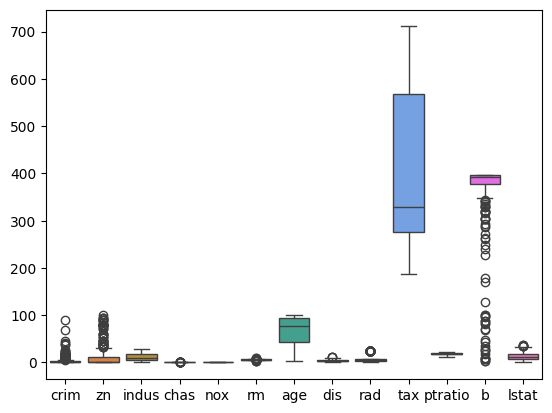

In [32]:
## check for outliers
sns.boxplot(X_train)

<Axes: >

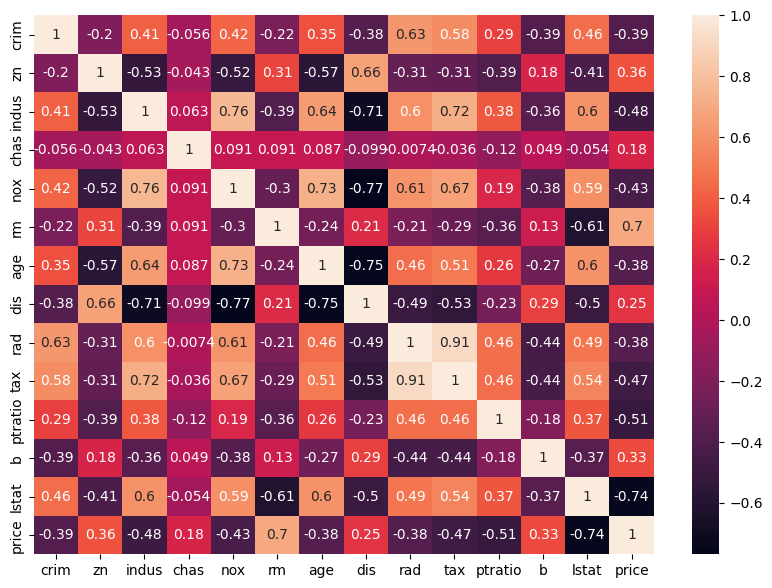

In [33]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)

In [34]:
from xgboost import XGBRegressor

model= XGBRegressor()
model.fit(X_train,y_train)

y_pred= model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error
score= r2_score(y_test,y_pred)
mae= mean_absolute_error(y_test,y_pred)
print(f"R2 Score: {score}")
print(f"MAE: {mae}")

R2 Score: 0.8253353715422231
MAE: 2.3230362809549163


In [35]:

input_data= [0.62976,0,8.14,0,0.538,5.949,61.8,4.7075,4,307,21,396.9,8.26]
input_arr= np.asarray(input_data).reshape(1,-1)
# input_arr_scaled= scaler.transform(input_arr)
prediction = model.predict(input_arr.reshape(1,-1))
print(prediction[0])


20.770395


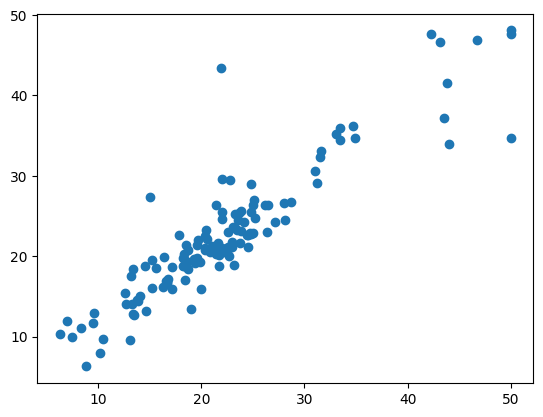

In [38]:
plt.scatter(y_test, model.predict(X_test))

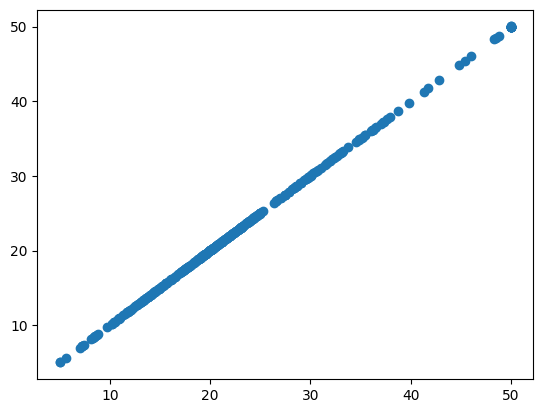

In [44]:
plt.scatter(y_train, model.predict(X_train))